# 04 — Model Evaluation, Calibration & Explainability

This notebook evaluates the selected benchmark candidate and produces model-agnostic explanations.

In [7]:
import sys, json, joblib
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score, f1_score, matthews_corrcoef, log_loss
import matplotlib.pyplot as plt
NB_DIR = Path.cwd()
if not (NB_DIR / 'notebook_utils.py').exists():
    NB_DIR = next(p for p in [NB_DIR, *NB_DIR.parents] if (p / 'src' / 'notebooks' / 'notebook_utils.py').exists()) / 'src' / 'notebooks'
sys.path.insert(0, str(NB_DIR))
from notebook_utils import *

In [8]:
raw_df, chosen = select_training_table()
df = standardize_training_table(raw_df)
X, y_text, FEATURE_NAMES = build_feature_table(df)
le = LabelEncoder()
y = le.fit_transform(y_text)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)
benchmark = pd.read_csv(PROCESSED_DIR / 'model_benchmark.csv')
best_name = benchmark.iloc[0]['Model']
model = joblib.load(PROCESSED_DIR / f'model_{safe_model_filename(best_name)}.joblib')
print('Selected:', best_name)
print('Classes:', list(le.classes_))

Selected: CatBoost
Classes: ['Combustion', 'HC immiscible', 'Hot water', 'Miscible CO2', 'Miscible HC', 'Miscible acid gas', 'Nitrogen immiscible', 'Polymer', 'Steam']


In [9]:
proba = model.predict_proba(X_test)
pred = np.argmax(proba, axis=1)

# Determine which class labels are actually being evaluated
labels_present = np.unique(np.concatenate([y_test, pred]))

# Use only the corresponding class names
target_names_present = le.inverse_transform(labels_present)

all_labels = np.arange(len(le.classes_))


In [10]:
print(
    classification_report(
        y_test,
        pred,
        labels=all_labels,
        target_names=le.classes_,
        zero_division=0
    )
)

print("Balanced accuracy:",
      balanced_accuracy_score(y_test, pred))

print("Macro F1:",
      f1_score(
          y_test,
          pred,
          labels=all_labels,
          average="macro",
          zero_division=0
      ))

print("MCC:",
      matthews_corrcoef(y_test, pred))

                     precision    recall  f1-score   support

         Combustion       1.00      1.00      1.00         5
      HC immiscible       0.00      0.00      0.00         0
          Hot water       1.00      1.00      1.00         1
       Miscible CO2       0.91      0.89      0.90        35
        Miscible HC       0.82      0.86      0.84        21
  Miscible acid gas       0.00      0.00      0.00         0
Nitrogen immiscible       1.00      1.00      1.00         1
            Polymer       1.00      1.00      1.00        24
              Steam       1.00      1.00      1.00        19

           accuracy                           0.93       106
          macro avg       0.75      0.75      0.75       106
       weighted avg       0.93      0.93      0.93       106

Balanced accuracy: 0.963265306122449
Macro F1: 0.7484177807736958
MCC: 0.9140281890086754


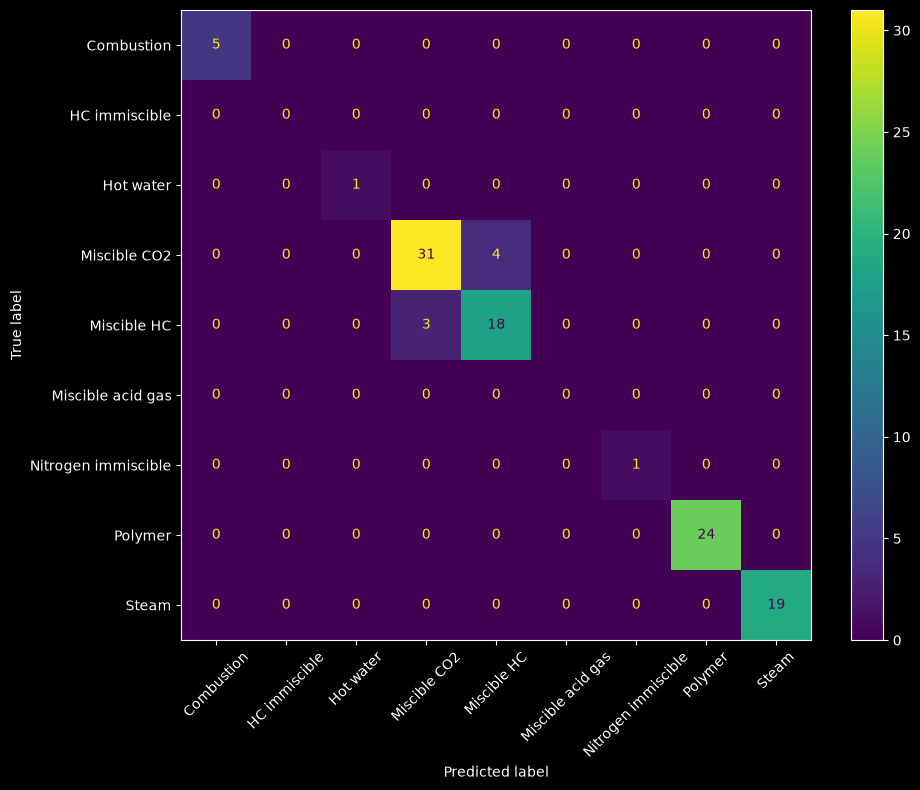

In [11]:
all_labels = np.arange(len(le.classes_))

cm = confusion_matrix( y_test, pred, labels=all_labels)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay( confusion_matrix=cm, display_labels=le.classes_)
disp.plot( ax=ax, xticks_rotation=45)

plt.tight_layout()
plt.show()



In [12]:
perm = permutation_importance(model, X_test, y_test, n_repeats=20, random_state=SEED, scoring='f1_macro', n_jobs=-1)
importance = pd.DataFrame({'Feature': FEATURE_NAMES, 'Importance_Mean': perm.importances_mean, 'Importance_STD': perm.importances_std}).sort_values('Importance_Mean', ascending=False)
display(importance.head(20))
importance.to_csv(PROCESSED_DIR / 'feature_importance.csv', index=False)

,Feature,Importance_Mean,Importance_STD
10,so_mid_pct,0.199377,0.044796
0,depth_mid_ft,0.153018,0.061683
6,api_mid,0.047033,0.024143
2,porosity_mid_pct,0.045690,0.023431
8,visc_mid_cp,0.016698,0.012208
12,log10_perm_mid,0.016425,0.014400
4,perm_mid_md,0.010788,0.008050
5,perm_span_md,0.007223,0.007898
9,visc_span_cp,0.006367,0.001461
7,api_span,0.006115,0.026656


### Research interpretation
Use these results to identify weak classes, confusable methods and dominant input variables. Permutation importance is model attribution, not physical causality. For XGBoost/CatBoost winners, add SHAP in a controlled follow-up analysis.